In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-13


# 1. Check clinical metadata

In [2]:
adata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/integrated/snRNAseq_microglia_cnmfr2_k8.h5ad")
adata

AnnData object with n_obs × n_vars = 41237 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8'
    var: 'mt', 'ribo', 'hb'
    obsm: 'X_umap_scVI'
    layers: 'counts

In [6]:
print(adata.obs['sample_id'].value_counts())

sample_id
P82_Donor5           3876
A76_Donor4           3452
G120_D.3             2923
P76_Donor4           2764
Patient-3_snRNA      2271
A56_Donor1           2099
A57_Donor2           2043
G133_N.2             1849
Patient-2_snRNA      1722
Patient-4_snRNA      1604
Control-3_snRNA      1585
A82_Donor5           1462
G133_D.2             1316
Patient-1_snRNA      1266
P57_Donor2           1169
Control-1_snRNA       915
Control-2_snRNA       889
RM95_snRNA_rep2       867
B01_total_nuclei      863
G129_D                810
RM77_snRNA_rep2       749
G210_D                616
RM95_snRNA_rep1       602
RM102_snRNA_rep1      502
RM77_snRNA_rep1       487
RM101_snRNA_rep2      444
RM102_snRNA_rep2      395
G120_D.2              385
P67_Donor3            365
A67_Donor3            276
HC14_total_nuclei     231
G159_D                216
G120_N.1               70
G187_D                 64
P56_Donor1             48
HC35_total_nuclei      18
G171_D                 15
G150_D                  9
Na

In [7]:
print(adata.obs['diagnosis_raw'].value_counts())
print(adata.obs['diagnosis_harmonized'].value_counts())

diagnosis_raw
cryptogenic temporal lobe epilepsy                                                   17554
FCD IIIa with hippocampal sclerosis                                                   6863
FCD_typeIIb                                                                           6266
temporal lobe epilepsy                                                                4046
isolated hippocampal sclerosis (iHS); relatively non-epileptic temporal neocortex     3389
Normal                                                                                1919
epilepsy; normal-appearing lateral temporal cortex                                     863
postmortem healthy control                                                             249
FCD_typeIIa                                                                             88
Name: count, dtype: int64
diagnosis_harmonized
nonlesional epilepsy    22463
FCD                     15136
HS                       3389
HC                        249


In [9]:
(
    adata.obs
    .groupby(["diagnosis_harmonized", "study"], observed=True)
    .agg(
        n_cells=("sample_id", "size"),
        n_samples=("sample_id", "nunique"),
        n_donors=("donor_id_global", "nunique"),
    )
)

n_cells  n_samples  n_donors
diagnosis_harmonized study                                   
FCD                  galvao         8273         11         8
                     liu            6863          4         4
HC                   pappalardo      249          2         2
HS                   liu            3389          3         3
nonlesional epilepsy ayhan         17554         10         5
                     pappalardo      863          1         1
                     thrupp         4046          7         4

# 2. Aggregate, generate pseudobulk

In [10]:
adata

AnnData object with n_obs × n_vars = 41237 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8'
    var: 'mt', 'ribo', 'hb'
    obsm: 'X_umap_scVI'
    layers: 'counts

In [12]:
from scipy import sparse


# ============================================================
# 0. Settings
# ============================================================

COUNT_LAYER = "counts"

meta_cols = [
    "study",
    "sample_id",
    "donor_id",
    "diagnosis_raw",
    "diagnosis_harmonized",
    "fcd_class",
    "mtoropathy_status",
    "tissue_state",
    "hemisphere",
    "age",
    "sex",
    "epilepsy_duration",
]

# only keep columns that actually exist
meta_cols = [c for c in meta_cols if c in adata.obs.columns]


# ============================================================
# 1. Check raw count matrix
# ============================================================

if COUNT_LAYER not in adata.layers:
    raise ValueError(f"`adata.layers['{COUNT_LAYER}']` does not exist.")

counts = adata.layers[COUNT_LAYER]

if not sparse.issparse(counts):
    counts = sparse.csr_matrix(counts)
else:
    counts = counts.tocsr()

if counts.data.min() < 0:
    raise ValueError("Count matrix contains negative values.")

# optional sanity check: raw counts should be integer-like
if not np.allclose(counts.data[:100000], np.round(counts.data[:100000])):
    print("WARNING: counts layer does not appear to contain integer raw counts.")


# ============================================================
# 2. Make globally unique pseudobulk ID
# ============================================================

adata.obs["pb_id"] = (
    adata.obs["study"].astype(str)
    + "::"
    + adata.obs["sample_id"].astype(str)
)

pb_ids = pd.Index(adata.obs["pb_id"].unique(), name="pb_id")

print(f"{adata.n_obs:,} cells")
print(f"{len(pb_ids):,} pseudobulk samples")


# ============================================================
# 3. Check that sample-level metadata are consistent
# ============================================================

for col in meta_cols:
    n_unique = (
        adata.obs.groupby("pb_id", observed=True)[col]
        .nunique(dropna=True)
    )

    bad = n_unique[n_unique > 1]

    if len(bad) > 0:
        print(f"\nWARNING: `{col}` has multiple values within these samples:")
        print(bad)


# ============================================================
# 4. Cell -> sample aggregation matrix
# ============================================================

pb_cat = pd.Categorical(
    adata.obs["pb_id"],
    categories=pb_ids,
)

row = pb_cat.codes
col = np.arange(adata.n_obs)

# matrix shape:
# n_samples × n_cells
sample_indicator = sparse.csr_matrix(
    (
        np.ones(adata.n_obs, dtype=np.int64),
        (row, col),
    ),
    shape=(len(pb_ids), adata.n_obs),
)

# sum raw counts over cells
# shape:
# n_samples × n_genes
pb_counts = sample_indicator @ counts
pb_counts = pb_counts.tocsr()


# ============================================================
# 5. Build sample metadata
# ============================================================

def first_non_null(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan


pb_obs = (
    adata.obs
    .groupby("pb_id", observed=True)[meta_cols]
    .agg(first_non_null)
    .reindex(pb_ids)
)

# number of microglia/nuclei contributing to each PB
pb_obs["n_cells"] = (
    adata.obs["pb_id"]
    .value_counts()
    .reindex(pb_ids)
    .astype(int)
)

# library size after aggregation
pb_obs["total_counts"] = np.asarray(pb_counts.sum(axis=1)).ravel()


# ============================================================
# 6. Construct pseudobulk AnnData
# ============================================================

pb = ad.AnnData(
    X=pb_counts.copy(),
    obs=pb_obs.copy(),
    var=adata.var.copy(),
)

# explicitly preserve raw counts
pb.layers["counts"] = pb_counts.copy()

pb.obs_names = pb_ids.astype(str)

print(pb)

41,237 cells
38 pseudobulk samples
AnnData object with n_obs × n_vars = 38 × 14642
    obs: 'study', 'sample_id', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'tissue_state', 'hemisphere', 'sex', 'n_cells', 'total_counts'
    var: 'mt', 'ribo', 'hb'
    layers: 'counts'


# 3. QC

In [13]:
pb.obs[
    [
        c for c in [
            "study",
            "sample_id",
            "donor_id",
            "diagnosis_harmonized",
            "diagnosis_raw",
            "n_cells",
            "total_counts",
        ]
        if c in pb.obs.columns
    ]
].sort_values(["study", "sample_id"])

,study,sample_id,diagnosis_harmonized,diagnosis_raw,n_cells,total_counts
pb_id,,,,,,
ayhan::A56_Donor1,ayhan,A56_Donor1,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,2099,1953897.0
ayhan::A57_Donor2,ayhan,A57_Donor2,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,2043,1567431.0
ayhan::A67_Donor3,ayhan,A67_Donor3,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,276,188826.0
ayhan::A76_Donor4,ayhan,A76_Donor4,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,3452,6105178.0
ayhan::A82_Donor5,ayhan,A82_Donor5,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,1462,2675347.0
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,48,36432.0
ayhan::P57_Donor2,ayhan,P57_Donor2,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,1169,875362.0
ayhan::P67_Donor3,ayhan,P67_Donor3,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,365,128828.0
ayhan::P76_Donor4,ayhan,P76_Donor4,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,2764,3898881.0


In [14]:
pb.obs["n_cells"].describe()

count      38.000000
mean     1085.184211
std       997.473426
min         9.000000
25%       370.000000
50%       836.500000
75%      1599.250000
max      3876.000000
Name: n_cells, dtype: float64

In [15]:
pb.obs.sort_values("n_cells")[
    [
        "study",
        "sample_id",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ]
]

,study,sample_id,diagnosis_harmonized,n_cells,total_counts
pb_id,,,,,
galvao::G150_D,galvao,G150_D,FCD,9,17026.0
galvao::G171_D,galvao,G171_D,FCD,15,21173.0
pappalardo::HC35_total_nuclei,pappalardo,HC35_total_nuclei,HC,18,16855.0
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,48,36432.0
galvao::G187_D,galvao,G187_D,FCD,64,51850.0
galvao::G120_N.1,galvao,G120_N.1,FCD,70,643950.0
galvao::G159_D,galvao,G159_D,FCD,216,457774.0
pappalardo::HC14_total_nuclei,pappalardo,HC14_total_nuclei,HC,231,436172.0
ayhan::A67_Donor3,ayhan,A67_Donor3,nonlesional epilepsy,276,188826.0


# 4. PCA

## Without QC

In [16]:
pb_pca = pb.copy()

# library-size normalization
sc.pp.normalize_total(pb_pca, target_sum=1e6)

# log-CPM
sc.pp.log1p(pb_pca)

# HVG
sc.pp.highly_variable_genes(
    pb_pca,
    n_top_genes=3000,
    flavor="seurat"
)

# PCA
sc.pp.pca(
    pb_pca,
    n_comps=20,
    mask_var="highly_variable"
)

normalizing counts per cell
    finished (0:00:03)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=20
    finished (0:00:00)


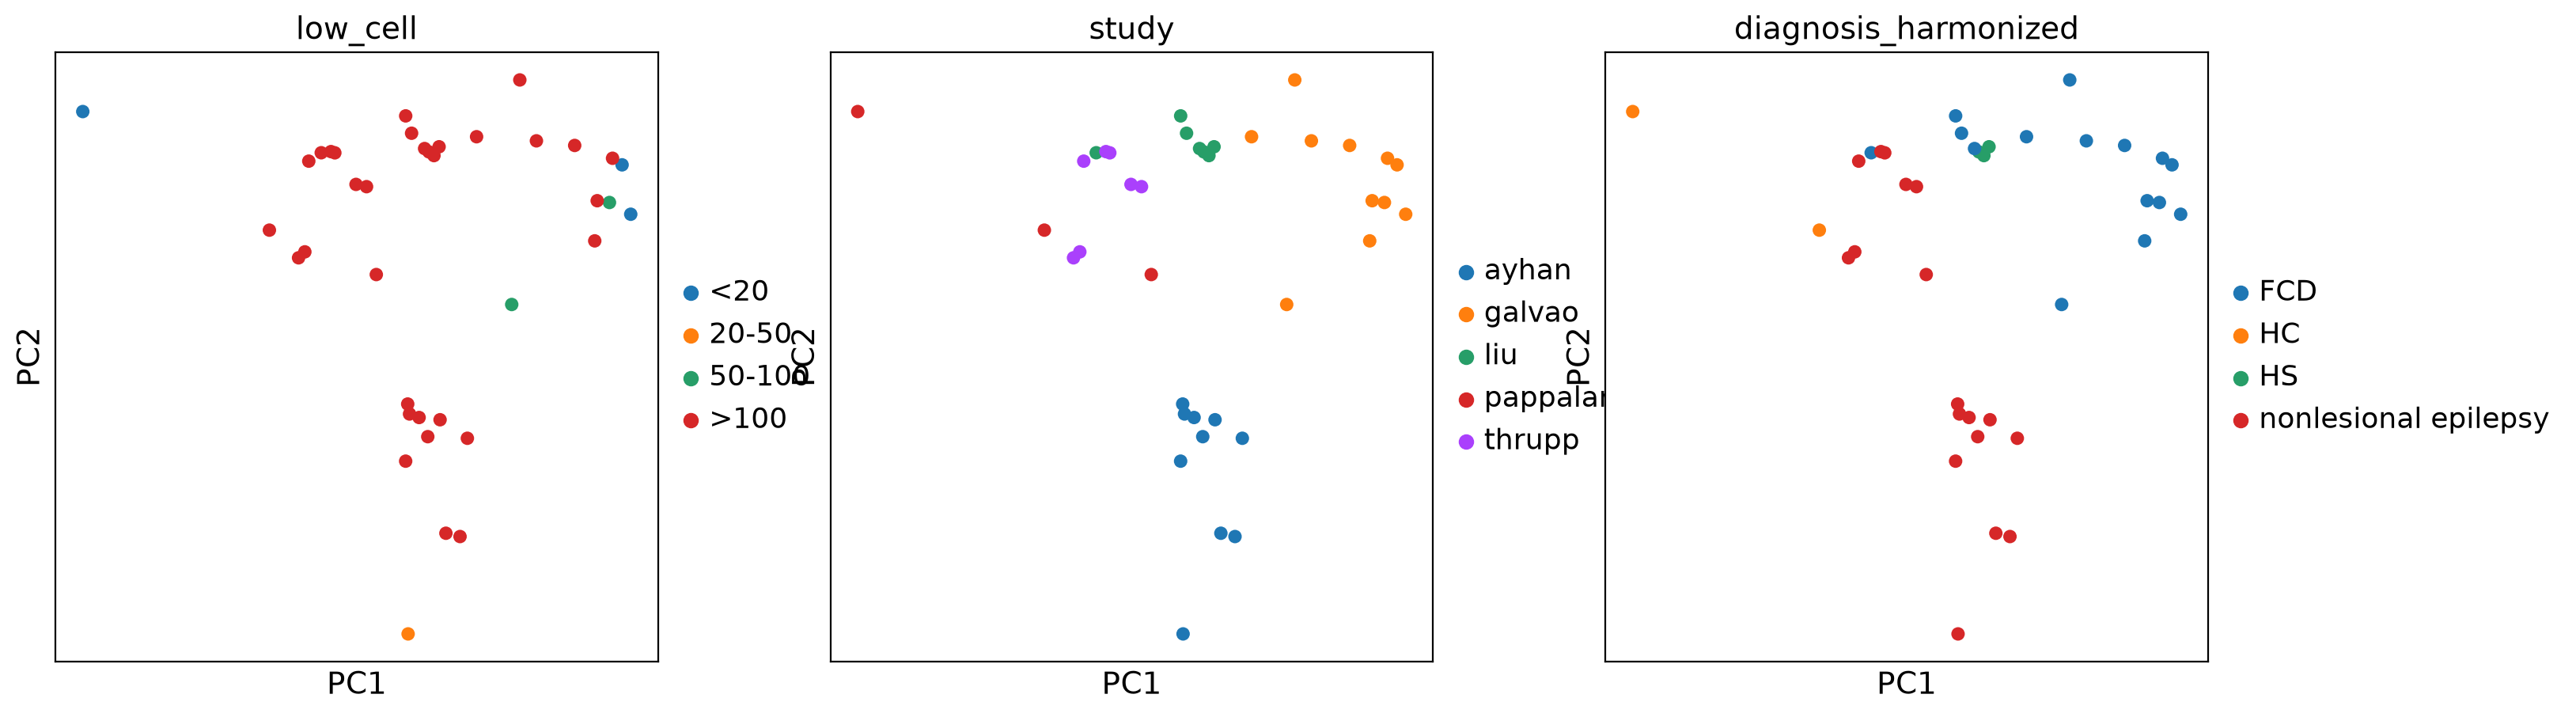

In [18]:
pb_pca.obs["low_cell"] = pd.cut(
    pb_pca.obs["n_cells"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["<20", "20-50", "50-100", ">100"]
)

sc.pl.pca(
    pb_pca,
    color=["low_cell", "study", "diagnosis_harmonized"],
    size=150,
)

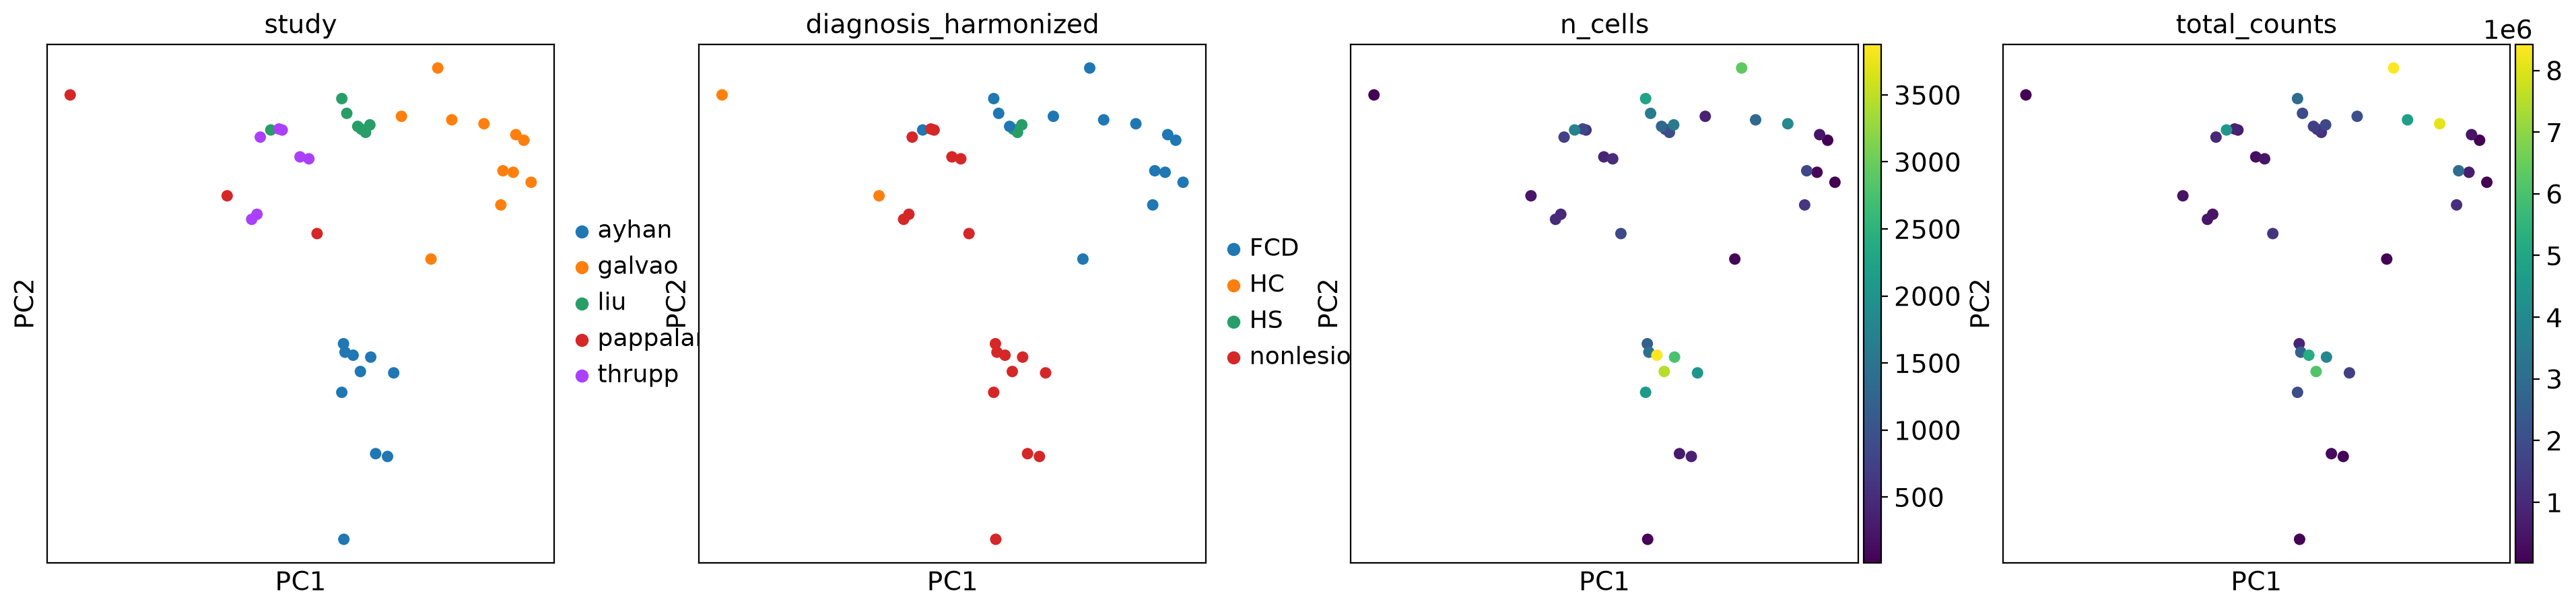

In [17]:
sc.pl.pca(
    pb_pca,
    color=[
        "study",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ],
    size=150,
)

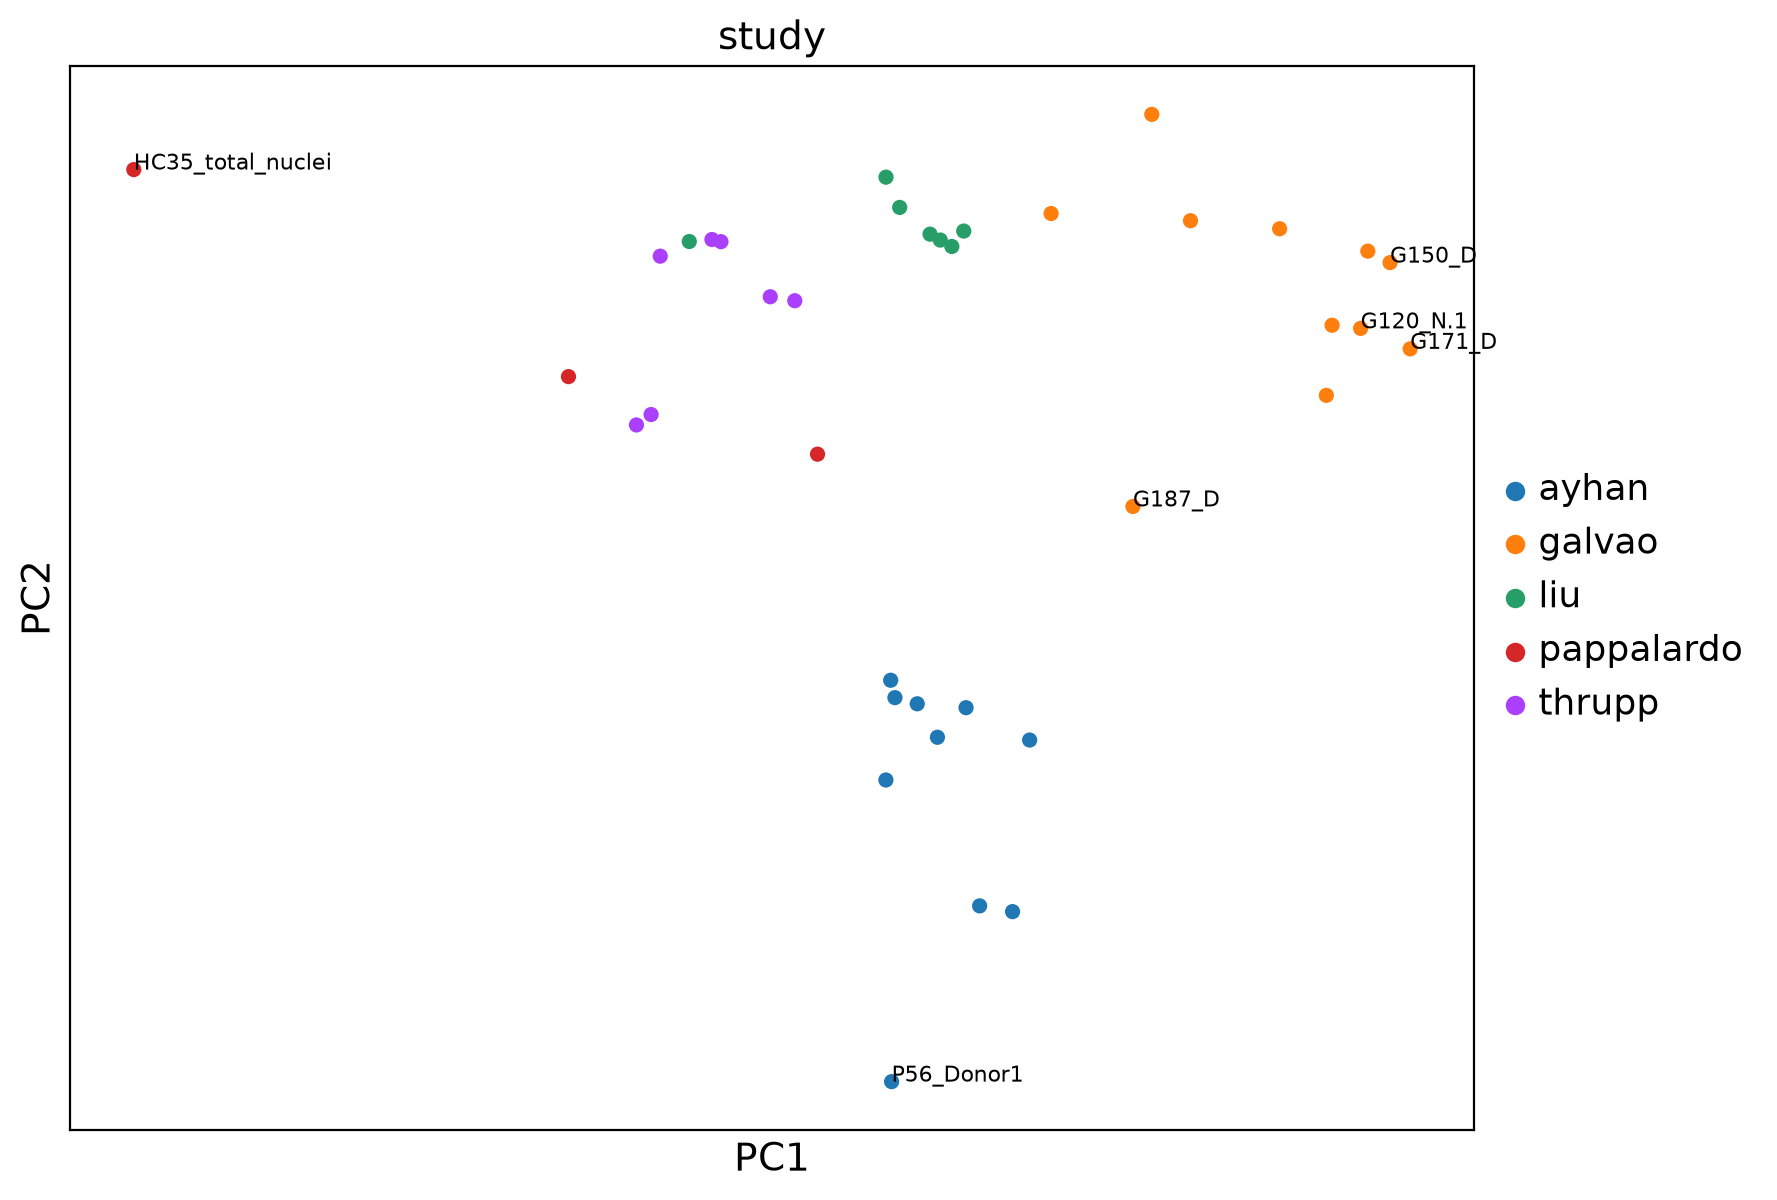

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.pca(
    pb_pca,
    color="study",
    size=120,
    ax=ax,
    show=False,
)

for i in range(pb_pca.n_obs):
    if pb_pca.obs.iloc[i]["n_cells"] < 100:
        ax.annotate(
            pb_pca.obs.iloc[i]["sample_id"],
            pb_pca.obsm["X_pca"][i, :2],
            fontsize=8,
        )

plt.show()

In [23]:
def pc_loadings_both_sides(adata, pc=1, n=20):
    s = pd.Series(
        adata.varm["PCs"][:, pc - 1],
        index=adata.var_names
    ).sort_values()

    negative = s.head(n).to_frame("loading")
    positive = s.tail(n).sort_values(ascending=False).to_frame("loading")

    return positive, negative

In [24]:
pc1_pos, pc1_neg = pc_loadings_both_sides(pb_pca, pc=1, n=30)

display(pc1_pos)
display(pc1_neg)

,loading
MIF,0.055770
PTGDS,0.055489
TMEM14B,0.053591
CALM2,0.053223
NDUFA13,0.052275
FXYD6,0.052080
RABGEF1,0.050574
TUBB3,0.050517
ARL6IP1,0.048119
CYP51A1,0.047561


,loading
FAM177B,-0.043858
OOEP,-0.037309
NAIP,-0.037206
TLR5,-0.034474
CD163,-0.033896
CMKLR1,-0.033508
HLA-DRB5,-0.033290
BAIAP2L1,-0.033166
MS4A6A,-0.032453
CSF3R,-0.032393


In [25]:
pc2_pos, pc2_neg = pc_loadings_both_sides(pb_pca, pc=2, n=30)

display(pc2_pos)
display(pc2_neg)

,loading
CALM2,0.076436
PTGDS,0.067244
ZNF37A,0.066192
PARL,0.064267
ATP1A3,0.064221
PAQR8,0.062734
DEPDC5,0.061049
RNASET2,0.058266
SLC35A3,0.057922
FXYD6,0.056635


,loading
SERPINE1,-0.071647
KIF19,-0.061896
LRP2,-0.060957
CERCAM,-0.057634
FKBP5,-0.057046
LDB3,-0.055139
ZBTB16,-0.053814
CLMN,-0.052785
LGR5,-0.052718
ITGA2,-0.052365


In [43]:
pb_pca.write("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/pseudobulk/snRNAseq_microglia_cnmfr2_k8_pb.h5ad")

In [26]:
def print_pc_genes(adata, pcs=(1, 2), n=30):
    for pc in pcs:
        s = pd.Series(
            adata.varm["PCs"][:, pc - 1],
            index=adata.var_names
        )

        print(f"\n===== PC{pc} POSITIVE =====")
        print(", ".join(s.nlargest(n).index))

        print(f"\n===== PC{pc} NEGATIVE =====")
        print(", ".join(s.nsmallest(n).index))


print_pc_genes(pb_pca, pcs=(1, 2), n=50)


===== PC1 POSITIVE =====
MIF, PTGDS, TMEM14B, CALM2, NDUFA13, FXYD6, RABGEF1, TUBB3, ARL6IP1, CYP51A1, PPP2CA, COX6A1, ACSL6, ARF3, ATF7, PDXP, STX16, NDUFA11, NEDD8, TIA1, COX8A, TRAPPC5, RNASEK, ATP1A3, STRADA, PFN2, GABARAP, TMEM151B, PRH1, LZTS3, NME1, KCNMB2, WDR83OS, ZNF10, SNRPN, FBXL16, NPDC1, ELAVL3, TNNI3K, MTAP, GFAP, CHD5, MTG1, CHKB, BLOC1S6, RNASET2, HSPE1, MRPL38, ABHD16A, DCTN1

===== PC1 NEGATIVE =====
FAM177B, OOEP, NAIP, TLR5, CD163, CMKLR1, HLA-DRB5, BAIAP2L1, MS4A6A, CSF3R, CMTM7, FRRS1, F13A1, PGM5, KCNK13, CIITA, ARL11, SPDYE5, ST8SIA4, ADGRG5, CLEC7A, MRC1, TIMM23B, MILR1, GGACT, MNDA, IL4R, AIF1, LY86, PLA2G4A, BLNK, FOLR2, EPSTI1, TLR1, IL18, C1orf162, CARD9, PLSCR1, CXCL12, CD300A, LYVE1, FKBP5, IL10RA, STAB1, LTBR, GNLY, MSR1, HPGDS, HLA-DQA1, TMC8

===== PC2 POSITIVE =====
CALM2, PTGDS, ZNF37A, PARL, ATP1A3, PAQR8, DEPDC5, RNASET2, SLC35A3, FXYD6, ARL6IP1, RPL18A, ALDOA, TIA1, RAD50, CHURC1, STX16, RPS18, FSTL4, TARDBP, ARF3, ACSL6, ST3GAL3, RPS27, NEDD8, 

## Low quality cell measure

In [20]:
import numpy as np
import pandas as pd

# distance from global PCA centroid using first 5 PCs
X = pb_pca.obsm["X_pca"][:, :5]

center = X.mean(axis=0)

pb_pca.obs["pca_distance"] = np.sqrt(
    ((X - center) ** 2).sum(axis=1)
)

pb_pca.obs[
    [
        "study",
        "sample_id",
        "n_cells",
        "total_counts",
        "pca_distance",
    ]
].sort_values("pca_distance", ascending=False)

,study,sample_id,n_cells,total_counts,pca_distance
pb_id,,,,,
pappalardo::HC35_total_nuclei,pappalardo,HC35_total_nuclei,18,16855.0,124.566994
galvao::G150_D,galvao,G150_D,9,17026.0,113.183914
galvao::G171_D,galvao,G171_D,15,21173.0,90.111885
galvao::G187_D,galvao,G187_D,64,51850.0,81.585083
ayhan::P56_Donor1,ayhan,P56_Donor1,48,36432.0,69.331215
galvao::G159_D,galvao,G159_D,216,457774.0,54.389172
galvao::G120_N.1,galvao,G120_N.1,70,643950.0,52.937519
pappalardo::HC14_total_nuclei,pappalardo,HC14_total_nuclei,231,436172.0,49.617645
ayhan::P67_Donor3,ayhan,P67_Donor3,365,128828.0,49.440430


In [21]:
X = pb_pca.obsm["X_pca"][:, :5]

dist = np.zeros(pb_pca.n_obs)

for study in pb_pca.obs["study"].unique():
    mask = pb_pca.obs["study"].values == study

    center = X[mask].mean(axis=0)

    dist[mask] = np.sqrt(
        ((X[mask] - center) ** 2).sum(axis=1)
    )

pb_pca.obs["within_study_pca_distance"] = dist

pb_pca.obs[
    [
        "study",
        "sample_id",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
        "within_study_pca_distance",
    ]
].sort_values(
    "within_study_pca_distance",
    ascending=False
)

,study,sample_id,diagnosis_harmonized,n_cells,total_counts,within_study_pca_distance
pb_id,,,,,,
galvao::G150_D,galvao,G150_D,FCD,9,17026.0,98.625870
galvao::G187_D,galvao,G187_D,FCD,64,51850.0,74.878883
pappalardo::HC35_total_nuclei,pappalardo,HC35_total_nuclei,HC,18,16855.0,68.943787
galvao::G171_D,galvao,G171_D,FCD,15,21173.0,68.715965
pappalardo::B01_total_nuclei,pappalardo,B01_total_nuclei,nonlesional epilepsy,863,1264683.0,48.545483
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,48,36432.0,35.796120
galvao::G120_D.2,galvao,G120_D.2,FCD,385,2024454.0,32.156528
liu::Patient-2_snRNA,liu,Patient-2_snRNA,FCD,1722,4496937.0,28.330263
galvao::G120_D.3,galvao,G120_D.3,FCD,2923,8420784.0,28.141453


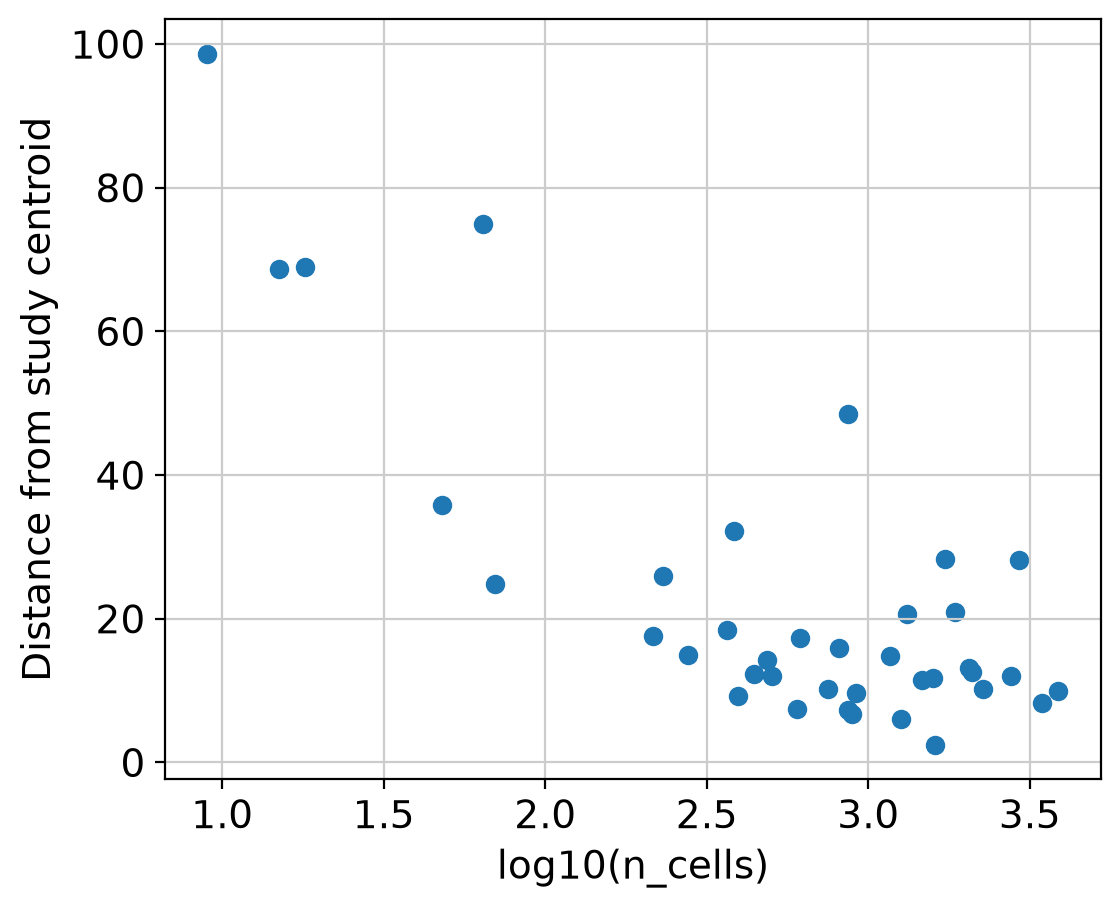

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    np.log10(pb_pca.obs["n_cells"]),
    pb_pca.obs["within_study_pca_distance"],
)

plt.xlabel("log10(n_cells)")
plt.ylabel("Distance from study centroid")

plt.show()

healthy (HC35)가 걸리지만 일단킵.

## With gene qc (min counts = 10 in min 3 samples)

In [27]:
X = pb.layers["counts"]

# expressed at >= 10 counts in at least 3 PB samples
keep = (
    np.asarray((X >= 10).sum(axis=0)).ravel()
    >= 3
)

pb_f = pb[:, keep].copy()

print(pb.n_vars, "->", pb_f.n_vars)

14642 -> 12741


In [28]:
# library-size normalization
sc.pp.normalize_total(pb_f, target_sum=1e6)

# log-CPM
sc.pp.log1p(pb_f)

# HVG
sc.pp.highly_variable_genes(
    pb_f,
    n_top_genes=3000,
    flavor="seurat"
)

# PCA
sc.pp.pca(
    pb_f,
    n_comps=20,
    mask_var="highly_variable"
)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=20
    finished (0:00:00)


In [40]:
pb_f.write("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/pseudobulk/snRNAseq_microglia_cnmfr2_k8_pb_genefiltered.h5ad")

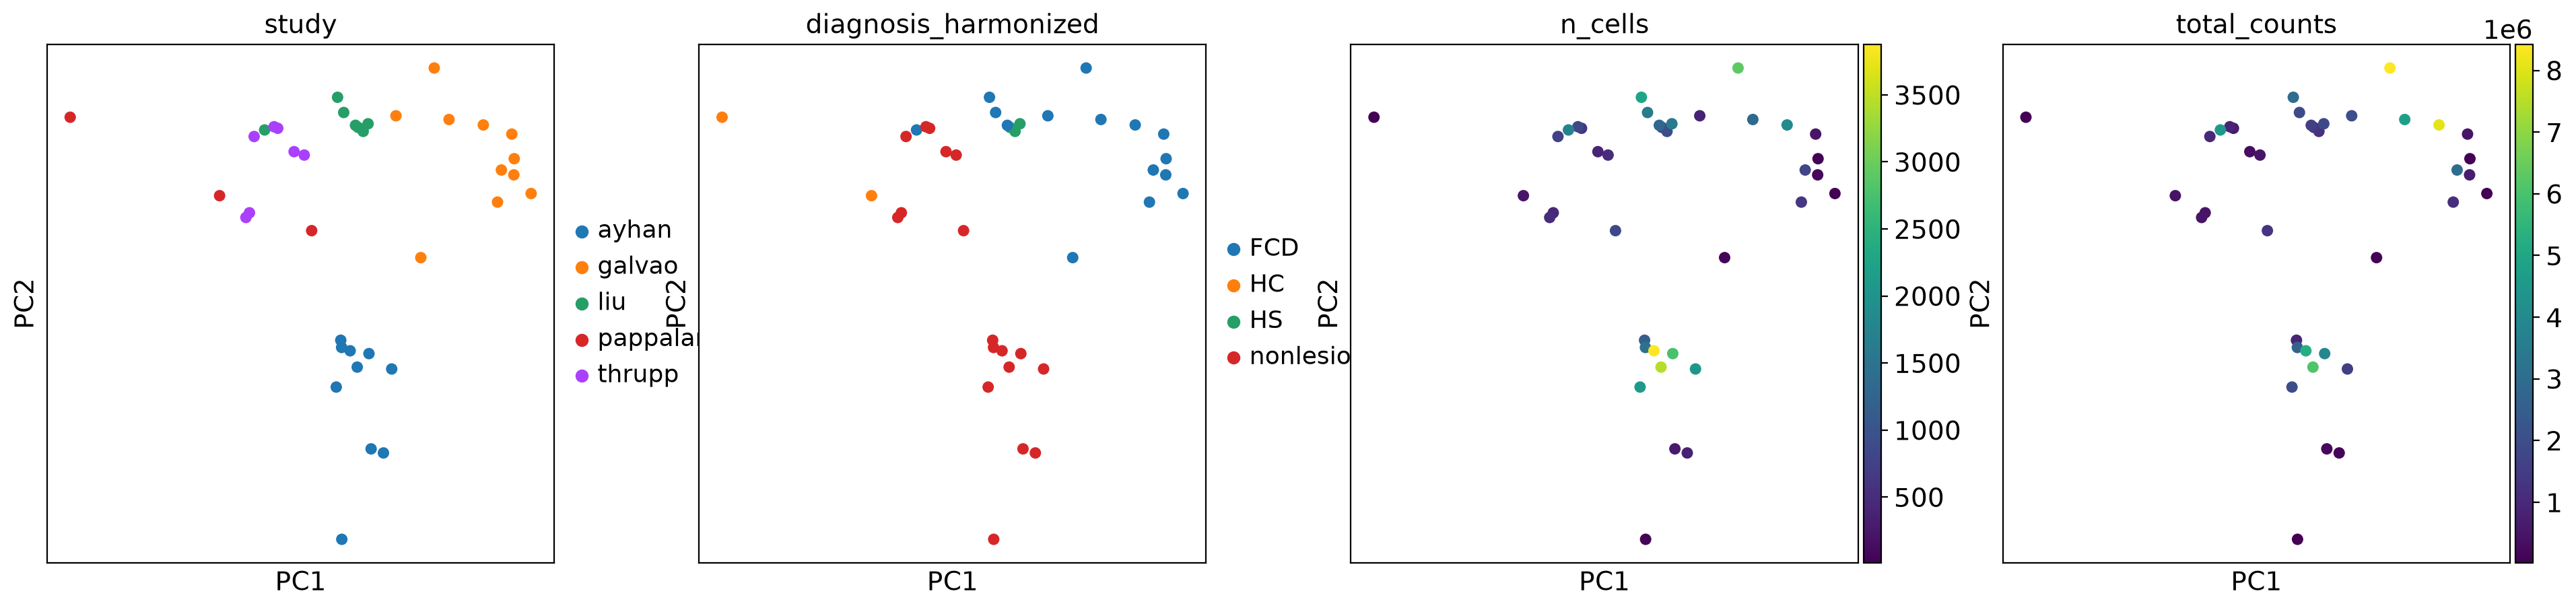

In [29]:
sc.pl.pca(
    pb_f,
    color=[
        "study",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ],
    size=150,
)

In [30]:
print_pc_genes(pb_f, pcs=(1, 2), n=50)


===== PC1 POSITIVE =====
MIF, PTGDS, TMEM14B, CALM2, NDUFA13, FXYD6, TUBB3, RABGEF1, ARL6IP1, CYP51A1, ACSL6, PPP2CA, COX6A1, ARF3, ATF7, PDXP, STX16, NDUFA11, TIA1, NEDD8, COX8A, TRAPPC5, RNASEK, ATP1A3, STRADA, PFN2, TMEM151B, PRH1, KCNMB2, LZTS3, GABARAP, NME1, NPDC1, WDR83OS, ZNF10, SNRPN, FBXL16, ELAVL3, TNNI3K, MTAP, GFAP, CHD5, BLOC1S6, MTG1, CHKB, RNASET2, HSPE1, MRPL38, ABHD16A, DCTN1

===== PC1 NEGATIVE =====
FAM177B, OOEP, GRAPL, NAIP, TLR5, CD163, CMKLR1, HLA-DRB5, BAIAP2L1, MS4A6A, CSF3R, CMTM7, FRRS1, KCNQ1, F13A1, PGM5, KCNK13, CIITA, ARL11, CLEC7A, SPDYE5, ADGRG5, TIMM23B, MILR1, MNDA, GGACT, LY86, AIF1, MRC1, PLA2G4A, IL4R, NFATC2, IL18, FOLR2, BLNK, DTX2, TLR1, EPSTI1, SAMSN1, CD300A, C1orf162, CXCL12, PLSCR1, CARD9, NCF4, IL10RA, ACSM5, NEDD9, LTBR, HLA-DQA1

===== PC2 POSITIVE =====
CALM2, PTGDS, ZNF37A, PARL, ATP1A3, PAQR8, DEPDC5, SLC35A3, RNASET2, FXYD6, ARL6IP1, AGGF1, ALDOA, RPL18A, COMMD7, RAD50, TIA1, TBCEL, CHURC1, STX16, TARDBP, RPS18, ST3GAL3, RPS27, FSTL

In [33]:
adata

AnnData object with n_obs × n_vars = 41237 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'pb_id'
    var: 'mt', 'ribo', 'hb'
    obsm: 'X_umap_scVI'
    layers

In [36]:
gep_cols = [f"GEP{i}" for i in range(1, 9)]

gep_by_sample = (
    adata.obs
    .groupby("sample_id")[gep_cols]
    .mean()
)

pb_f.obs[gep_cols] = gep_by_sample.reindex(
    pb_f.obs["sample_id"]
).to_numpy()

/tmp/ipykernel_3554039/2118979910.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample_id")[gep_cols]


In [37]:
pb_f.obs

,study,sample_id,diagnosis_raw,diagnosis_harmonized,fcd_class,mtoropathy_status,tissue_state,hemisphere,sex,n_cells,total_counts,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8
pb_id,,,,,,,,,,,,,,,,,,,
ayhan::A57_Donor2,ayhan,A57_Donor2,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,2043,1567431.0,0.082915,0.196239,0.391175,0.016262,0.112631,0.087368,0.045120,0.068291
ayhan::A56_Donor1,ayhan,A56_Donor1,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,2099,1953897.0,0.250159,0.340578,0.330702,0.028493,0.009119,0.011634,0.022267,0.007048
ayhan::P76_Donor4,ayhan,P76_Donor4,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,2764,3898881.0,0.068509,0.451307,0.201672,0.008160,0.151550,0.057328,0.035715,0.025759
ayhan::A76_Donor4,ayhan,A76_Donor4,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,3452,6105178.0,0.104437,0.429214,0.260290,0.009745,0.090316,0.067548,0.027354,0.011097
ayhan::P82_Donor5,ayhan,P82_Donor5,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,3876,5208322.0,0.193899,0.379901,0.234334,0.016183,0.075397,0.034336,0.026917,0.039032
ayhan::A82_Donor5,ayhan,A82_Donor5,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,1462,2675347.0,0.169085,0.434012,0.245019,0.019695,0.045683,0.042522,0.020398,0.023586
ayhan::P67_Donor3,ayhan,P67_Donor3,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,365,128828.0,0.082146,0.134657,0.600473,0.049149,0.024184,0.028922,0.047585,0.032884
ayhan::P56_Donor1,ayhan,P56_Donor1,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,48,36432.0,0.043675,0.191461,0.543456,0.023221,0.054731,0.025544,0.068430,0.049482
ayhan::A67_Donor3,ayhan,A67_Donor3,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,276,188826.0,0.056328,0.254737,0.575385,0.040919,0.007890,0.014757,0.027781,0.022202


In [45]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP1"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=-0.748, p=6.7e-08
PC2: rho=0.531, p=0.000603


In [44]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP2"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=-0.554, p=0.000312
PC2: rho=-0.435, p=0.00629


In [46]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP4"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=0.341, p=0.0364
PC2: rho=0.435, p=0.00629


In [47]:
# correlation bw GEPs

gep_cols = [f"GEP{i}" for i in range(1, 9)]

pb_f.obs[gep_cols].corr(method="spearman").round(2)

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8
GEP1,1.00,0.14,-0.80,0.03,-0.45,-0.50,-0.73,-0.28
GEP2,0.14,1.00,-0.01,-0.58,-0.38,-0.39,-0.46,-0.05
GEP3,-0.80,-0.01,1.00,-0.17,0.19,0.27,0.53,0.13
GEP4,0.03,-0.58,-0.17,1.00,-0.15,-0.14,0.13,-0.27
GEP5,-0.45,-0.38,0.19,-0.15,1.00,0.93,0.76,0.50
GEP6,-0.50,-0.39,0.27,-0.14,0.93,1.00,0.73,0.51
GEP7,-0.73,-0.46,0.53,0.13,0.76,0.73,1.00,0.44
GEP8,-0.28,-0.05,0.13,-0.27,0.50,0.51,0.44,1.00


In [48]:
from scipy.stats import spearmanr
import pandas as pd

pcs = {
    "PC1": pb_f.obsm["X_pca"][:, 0],
    "PC2": pb_f.obsm["X_pca"][:, 1],
}

rows = []

for gep in gep_cols:
    for pc_name, pc_values in pcs.items():
        rho, p = spearmanr(
            pb_f.obs[gep],
            pc_values,
            nan_policy="omit"
        )

        rows.append({
            "GEP": gep,
            "PC": pc_name,
            "rho": rho,
            "p": p
        })

corr_df = pd.DataFrame(rows)

print(
    corr_df
    .pivot(index="GEP", columns="PC", values="rho")
    .round(3)
    .to_string()
)

PC      PC1    PC2
GEP               
GEP1 -0.748  0.531
GEP2 -0.554 -0.435
GEP3  0.560 -0.750
GEP4  0.341  0.435
GEP5  0.590  0.188
GEP6  0.668  0.152
GEP7  0.790 -0.090
GEP8  0.180 -0.061
